# Phase Classification — Simple Spatial GCN

Classifies exercise phases at the **frame level** using a 2-layer Graph Convolutional Network.
Each frame is treated as a skeleton graph: joints are nodes, skeleton edges define the adjacency.
Two GCN layers aggregate neighbour joint features → global mean pool → linear classifier.

Same experiments / cross-fold evaluation / visualisations as the tree-based notebooks.

In [1]:
import json
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# ── Shared config ─────────────────────────────────────────────────────────────
SPLITS_PATH = "/code/jjiang23/pathml/aim2_balanceV2/data/splits.json"
PHASE_NAMES = ["Phase1", "Phase2", "Phase3", "Phase4"]

LABEL_MAP = {
    b"Phase1":   0,
    b"Phase2":   1,
    b"Phase3":   2,
    b"Phase4":   3,
    b"nonphase": 4,   # excluded
}

GCN_PARAMS = dict(
    hidden_dim   = 64,
    num_classes  = 4,
    dropout      = 0.3,
    lr           = 1e-3,
    weight_decay = 1e-4,
    epochs       = 80,
    batch_size   = 512,
    patience     = 10,
)

EXPERIMENTS = [
    {
        "name":          "MPW Full (33J)",
        "h5_key":        "world_mp_cropped_iou",
        "joint_indices": None,
        "n_joints":      33,
        "skeleton":      "mediapipe",
    },
    {
        "name":          "MPW Bottom Half (10J)",
        "h5_key":        "world_mp_cropped_iou",
        "joint_indices": list(range(23, 33)),
        "n_joints":      10,
        "skeleton":      "mediapipe",
    },
    {
        "name":          "MPW Top Half (12J)",
        "h5_key":        "world_mp_cropped_iou",
        "joint_indices": list(range(11, 23)),   # shoulders → wrists
        "n_joints":      12,
        "skeleton":      "mediapipe",
    },
    {
        "name":          "MotionBert Full (17J)",
        "h5_key":        "motionBert_cropped_iou",
        "joint_indices": None,
        "n_joints":      17,
        "skeleton":      "h36m",
    },
    {
        "name":          "MotionBert Bottom Half (7J)",
        "h5_key":        "motionBert_cropped_iou",
        "joint_indices": list(range(0, 7)),
        "n_joints":      7,
        "skeleton":      "h36m",
    },
    {
        "name":          "MotionBert Top Half (10J)",
        "h5_key":        "motionBert_cropped_iou",
        "joint_indices": list(range(7, 17)),
        "n_joints":      10,
        "skeleton":      "h36m",
    },
]

with open(SPLITS_PATH) as f:
    splits = json.load(f)

print(f"Folds: {list(splits.keys())}")
print(f"Experiments: {[e['name'] for e in EXPERIMENTS]}")

Folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']
Experiments: ['MPW Full (33J)', 'MPW Bottom Half (10J)', 'MPW Top Half (12J)', 'MotionBert Full (17J)', 'MotionBert Bottom Half (7J)', 'MotionBert Top Half (10J)']


In [3]:
# ── Skeleton adjacency definitions ────────────────────────────────────────────

# MediaPipe 33-joint edges (0-indexed, from the MediaPipe Pose topology)
MP_EDGES_33 = [
    # face
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),
    # shoulders
    (11,12),
    # left arm
    (11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    # right arm
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    # torso
    (11,23),(12,24),(23,24),
    # left leg
    (23,25),(25,27),(27,29),(27,31),(29,31),
    # right leg
    (24,26),(26,28),(28,30),(28,32),(30,32),
]

# Human3.6M 17-joint edges used by MotionBert
# 0=Hip,1=RHip,2=RKnee,3=RAnkle,4=LHip,5=LKnee,6=LAnkle,
# 7=Spine,8=Thorax,9=Neck,10=Head,
# 11=LShoulder,12=LElbow,13=LWrist,14=RShoulder,15=RElbow,16=RWrist
H36_EDGES_17 = [
    (0,1),(1,2),(2,3),           # right leg
    (0,4),(4,5),(5,6),           # left leg
    (0,7),(7,8),(8,9),(9,10),    # spine to head
    (8,11),(11,12),(12,13),      # left arm
    (8,14),(14,15),(15,16),      # right arm
]


def build_adj(n_joints, edges, joint_indices=None):
    """
    Build a symmetric, row-normalised (D^{-1/2} A D^{-1/2}) adjacency
    matrix as a torch float32 tensor of shape (J, J).

    If joint_indices is given, only retain edges whose both endpoints are
    in the subset, then re-index to 0..len(joint_indices)-1.
    """
    if joint_indices is not None:
        idx_set = set(joint_indices)
        remap   = {old: new for new, old in enumerate(joint_indices)}
        edges   = [(remap[u], remap[v])
                   for u, v in edges
                   if u in idx_set and v in idx_set]
        n_joints = len(joint_indices)

    A = np.zeros((n_joints, n_joints), dtype=np.float32)
    for u, v in edges:
        A[u, v] = 1.0
        A[v, u] = 1.0
    # Self-loops
    np.fill_diagonal(A, 1.0)
    # Symmetric normalisation: D^{-1/2} A D^{-1/2}
    D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1)))
    A_hat = D_inv_sqrt @ A @ D_inv_sqrt
    return torch.tensor(A_hat, dtype=torch.float32)


def get_adj(exp):
    skeleton = exp['skeleton']
    ji       = exp['joint_indices']
    if skeleton == 'mediapipe':
        return build_adj(33, MP_EDGES_33, ji)
    else:  # h36m
        return build_adj(17, H36_EDGES_17, ji)


# Sanity check
for exp in EXPERIMENTS:
    A = get_adj(exp)
    print(f"{exp['name']:<30} A={A.shape}")

MPW Full (33J)                 A=torch.Size([33, 33])
MPW Bottom Half (10J)          A=torch.Size([10, 10])
MPW Top Half (12J)             A=torch.Size([12, 12])
MotionBert Full (17J)          A=torch.Size([17, 17])
MotionBert Bottom Half (7J)    A=torch.Size([7, 7])
MotionBert Top Half (10J)      A=torch.Size([10, 10])


In [4]:
# ── Simple 2-layer GCN model ──────────────────────────────────────────────────

class GCNLayer(nn.Module):
    """Single GCN layer: H' = σ(A_hat H W)"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, A, x):
        # x: (B, J, F)   A: (J, J)
        h = self.W(x)                              # (B, J, out)
        h = torch.einsum('jk,bkd->bjd', A, h)     # (B, J, out)  — aggregate
        return h


class SkeletonGCN(nn.Module):
    """
    2-layer spatial GCN for per-frame skeleton classification.

    Input  : (B, J, 3)  — batch of skeleton frames, one graph per frame
    Output : (B, num_classes)  — logits
    """
    def __init__(self, in_features, hidden_dim, num_classes, A, dropout=0.3):
        super().__init__()
        self.register_buffer('A', A)
        self.gc1 = GCNLayer(in_features, hidden_dim)
        self.gc2 = GCNLayer(hidden_dim,  hidden_dim)
        self.drop = nn.Dropout(dropout)
        self.bn1  = nn.BatchNorm1d(hidden_dim)
        self.bn2  = nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (B, J*3)  — flattened input from data loader
        B = x.size(0)
        J = self.A.size(0)
        x = x.view(B, J, -1)                       # (B, J, 3)

        h = F.relu(self.gc1(self.A, x))             # (B, J, hidden)
        # BN expects (B, C) or (B, C, *) — reshape to (B*J, hidden)
        h = self.bn1(h.reshape(B * J, -1)).reshape(B, J, -1)
        h = self.drop(h)

        h = F.relu(self.gc2(self.A, h))             # (B, J, hidden)
        h = self.bn2(h.reshape(B * J, -1)).reshape(B, J, -1)
        h = self.drop(h)

        h = h.mean(dim=1)                           # global mean pool → (B, hidden)
        return self.classifier(h)                   # (B, num_classes)

In [5]:
# ── Data loaders ──────────────────────────────────────────────────────────────

def load_phase_frames(h5_paths, h5_key, joint_indices=None):
    """Returns X: (N, J*3) float32,  y: (N,) int32."""
    Xs, ys = [], []
    for path in h5_paths:
        try:
            with h5py.File(path, 'r') as f:
                if h5_key not in f:
                    continue
                raw = f[h5_key][:]
                kp  = (raw[:, 0, :, :3] if raw.ndim == 4 else raw[:, :, :3]).astype(np.float32)
                raw_labels = f['camera_poses_labels'][:]
        except Exception as e:
            print(f"  Skipping {path}: {e}")
            continue
        labels = np.array([LABEL_MAP[lbl] for lbl in raw_labels], dtype=np.int32)
        kp     = np.nan_to_num(kp)
        if joint_indices is not None:
            kp = kp[:, joint_indices, :]
        mask = labels < 4
        if mask.sum() == 0:
            continue
        T, J, D = kp[mask].shape
        Xs.append(kp[mask].reshape(T, J * D))
        ys.append(labels[mask])
    if not Xs:
        return np.empty((0, 0), dtype=np.float32), np.empty((0,), dtype=np.int32)
    return np.concatenate(Xs), np.concatenate(ys)


def load_phase_frames_with_segments(h5_paths, h5_key, joint_indices=None):
    Xs, y_frames, seg_ids_all, seg_true = [], [], [], []
    seg_counter = 0
    for path in h5_paths:
        try:
            with h5py.File(path, 'r') as f:
                if h5_key not in f:
                    continue
                raw = f[h5_key][:]
                kp  = (raw[:, 0, :, :3] if raw.ndim == 4 else raw[:, :, :3]).astype(np.float32)
                raw_labels = f['camera_poses_labels'][:]
        except Exception:
            continue
        labels = np.array([LABEL_MAP[lbl] for lbl in raw_labels], dtype=np.int32)
        kp     = np.nan_to_num(kp)
        if joint_indices is not None:
            kp = kp[:, joint_indices, :]
        mask = labels < 4
        if mask.sum() == 0:
            continue
        kp_ph, lbl_ph = kp[mask], labels[mask]
        T, J, D = kp_ph.shape
        changes    = np.where(np.diff(lbl_ph) != 0)[0] + 1
        boundaries = np.concatenate([[0], changes, [T]])
        seg_ids_video = np.empty(T, dtype=np.int64)
        for start, end in zip(boundaries[:-1], boundaries[1:]):
            seg_ids_video[start:end] = seg_counter
            seg_true.append(lbl_ph[start])
            seg_counter += 1
        Xs.append(kp_ph.reshape(T, J * D))
        y_frames.append(lbl_ph)
        seg_ids_all.append(seg_ids_video)
    if not Xs:
        return (np.empty((0, 0), dtype=np.float32), np.empty((0,), dtype=np.int32),
                np.empty((0,), dtype=np.int64),      np.empty((0,), dtype=np.int32))
    return (np.concatenate(Xs), np.concatenate(y_frames),
            np.concatenate(seg_ids_all), np.array(seg_true, dtype=np.int32))


def majority_vote(y_pred, seg_ids, seg_true):
    unique_segs = np.unique(seg_ids)
    y_pred_seg  = np.array([np.bincount(y_pred[seg_ids == s]).argmax() for s in unique_segs])
    y_true_seg  = np.array([seg_true[i] for i, _ in enumerate(unique_segs)])
    seg_f1 = f1_score(y_true_seg, y_pred_seg, average='macro', zero_division=0)
    return y_pred_seg, y_true_seg, seg_f1

In [6]:
# ── Training / evaluation helpers ─────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    preds, trues = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        logits  = model(X_batch)
        preds.append(logits.argmax(1).cpu().numpy())
        trues.append(y_batch.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    val_f1 = f1_score(trues, preds, average='macro', zero_division=0)
    return val_f1, preds


def train_gcn(model, X_train, y_train, X_val, y_val, params):
    """
    Train model with early stopping on val macro-F1. Returns best val predictions.
    """
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long),
    )
    train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=params['batch_size'], shuffle=False, num_workers=0)

    # Class-weighted loss to handle imbalance
    counts  = np.bincount(y_train, minlength=params['num_classes']).astype(np.float32)
    weights = torch.tensor(1.0 / (counts + 1e-6)).to(DEVICE)
    weights = weights / weights.sum() * params['num_classes']
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=params['epochs'], eta_min=1e-5
    )

    best_f1, best_preds, patience_counter = 0.0, None, 0
    best_state = None

    for epoch in range(1, params['epochs'] + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_f1, val_preds     = eval_epoch(model, val_loader)
        scheduler.step()

        if val_f1 > best_f1:
            best_f1   = val_f1
            best_preds = val_preds.copy()
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"    epoch {epoch:3d}  loss={train_loss:.4f}  "
                  f"train_acc={train_acc:.4f}  val_f1={val_f1:.4f}  "
                  f"best={best_f1:.4f}")

        if patience_counter >= params['patience']:
            print(f"    Early stop at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_f1, best_preds

In [7]:
# ── Run all experiments × all folds ──────────────────────────────────────────
all_results = {}

for exp in EXPERIMENTS:
    exp_name = exp['name']
    print(f"\n{'#'*70}")
    print(f"  EXPERIMENT: {exp_name}")
    print(f"{'#'*70}")

    A = get_adj(exp).to(DEVICE)
    fold_results = []

    for fold_name, fold_data in splits.items():
        print(f"\n  {'='*56}")
        print(f"  {fold_name}")
        print(f"  {'='*56}")

        X_train, y_train = load_phase_frames(
            fold_data['train'], exp['h5_key'], exp['joint_indices'])
        X_val, y_val, seg_ids_val, seg_true_val = load_phase_frames_with_segments(
            fold_data['val'], exp['h5_key'], exp['joint_indices'])

        n_segs = len(np.unique(seg_ids_val)) if len(seg_ids_val) else 0
        print(f"  train: {X_train.shape[0]:,} frames  "
              f"val: {X_val.shape[0]:,} frames ({n_segs} segments)  "
              f"features: {X_train.shape[1] if len(X_train) else 0}")

        if X_train.shape[0] == 0 or X_val.shape[0] == 0:
            print("  Skipping — empty split")
            continue

        in_features = X_train.shape[1] // exp['n_joints']   # = 3 (x,y,z per joint)
        model = SkeletonGCN(
            in_features = in_features,
            hidden_dim  = GCN_PARAMS['hidden_dim'],
            num_classes = GCN_PARAMS['num_classes'],
            A           = A,
            dropout     = GCN_PARAMS['dropout'],
        ).to(DEVICE)

        best_f1, y_pred_frame = train_gcn(
            model, X_train, y_train, X_val, y_val, GCN_PARAMS
        )

        frame_f1 = best_f1
        y_pred_seg, y_true_seg, seg_f1 = majority_vote(
            y_pred_frame, seg_ids_val, seg_true_val)

        print(f"\n  Frame macro-F1:   {frame_f1:.4f}")
        print(f"  Segment macro-F1: {seg_f1:.4f}  ({n_segs} segments)")
        print(classification_report(y_true_seg, y_pred_seg,
                                    target_names=PHASE_NAMES, digits=3))

        fold_results.append({
            "fold":       fold_name,
            "frame_f1":   frame_f1,
            "seg_f1":     seg_f1,
            "y_val":      y_val,
            "y_pred":     y_pred_frame,
            "cm_frame":   confusion_matrix(y_val,      y_pred_frame),
            "y_true_seg": y_true_seg,
            "y_pred_seg": y_pred_seg,
            "cm_seg":     confusion_matrix(y_true_seg, y_pred_seg),
        })

    all_results[exp_name] = fold_results


######################################################################
  EXPERIMENT: MPW Full (33J)
######################################################################



  fold_0


  train: 84,773 frames  val: 19,972 frames (73 segments)  features: 99


    epoch   1  loss=1.2024  train_acc=0.4618  val_f1=0.5063  best=0.5063


    epoch  10  loss=0.7528  train_acc=0.6863  val_f1=0.6195  best=0.6333


...

    Early stop at epoch 28

  Frame macro-F1:   0.3148
  Segment macro-F1: 0.3442  (74 segments)
              precision    recall  f1-score   support

      Phase1      0.353     0.300     0.324        20
      Phase2      0.333     0.300     0.316        20
      Phase3      0.345     0.526     0.417        19
      Phase4      0.400     0.267     0.320        15

    accuracy                          0.351        74
   macro avg      0.358     0.348     0.344        74
weighted avg      0.355     0.351     0.345        74


  fold_4


  train: 84,124 frames  val: 20,621 frames (75 segments)  features: 30


    epoch   1  loss=1.3344  train_acc=0.3091  val_f1=0.2588  best=0.2588


    epoch  10  loss=1.1826  train_acc=0.4036  val_f1=0.2303  best=0.2649


    Early stop at epoch 12

  Frame macro-F1:   0.2649
  Segment macro-F1: 0.2615  (75 segments)
              precision    recall  f1-score   support

      Phase1      0.222     0.190     0.205        21
      Phase2      0.238     0.250     0.244        20
      Phase3      0.333     0.150     0.207        20
      Phase4      0.296     0.571     0.390        14

    accuracy                          0.267        75
   macro avg      0.272     0.290     0.262        75
weighted avg      0.270     0.267     0.250        75



                             Frame F1 Mean  Frame F1 Std  Segment F1 Mean  Segment F1 Std  N Folds
Experiment                                                                                        
MPW Full (33J)                      0.6393        0.0351           0.6410          0.0421        5
MPW Bottom Half (10J)               0.6515        0.0472           0.6693          0.0541        5
MPW Top Half (12J)                  0.3013        0.0280           0.3153          0.0322        5
MotionBert Full (17J)               0.5403        0.0486           0.5422          0.0432        5
MotionBert Bottom Half (7J)         0.5916        0.0492           0.5726          0.0518        5
MotionBert Top Half (10J)           0.3232        0.0429           0.3378          0.0534        5


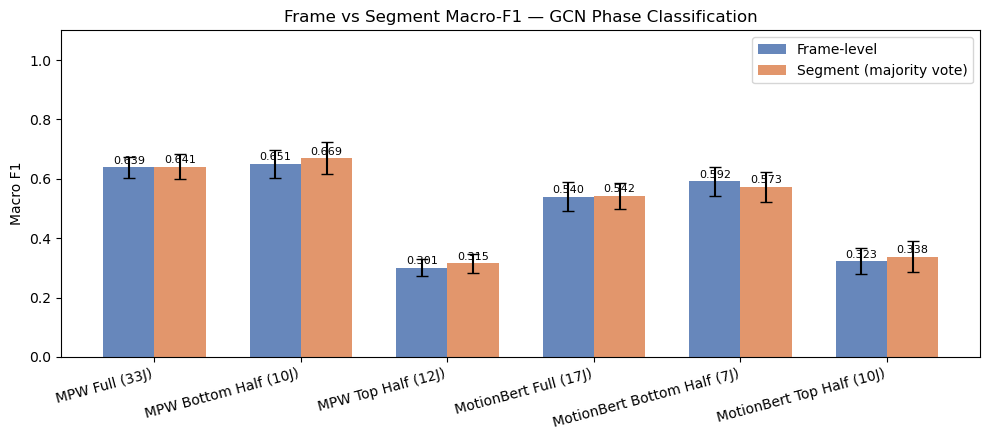

In [8]:
# ── Cross-experiment macro-F1 summary ─────────────────────────────────────────
summary_rows = []
for exp_name, fold_results in all_results.items():
    if not fold_results:
        continue
    frame_f1s = [r['frame_f1'] for r in fold_results]
    seg_f1s   = [r['seg_f1']   for r in fold_results]
    summary_rows.append({
        'Experiment':      exp_name,
        'Frame F1 Mean':   np.mean(frame_f1s),
        'Frame F1 Std':    np.std(frame_f1s),
        'Segment F1 Mean': np.mean(seg_f1s),
        'Segment F1 Std':  np.std(seg_f1s),
        'N Folds':         len(frame_f1s),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Experiment')
print(df_summary.to_string(float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(10, 4.5))
x, w   = np.arange(len(df_summary)), 0.35
bars_f = ax.bar(x - w/2, df_summary['Frame F1 Mean'],   w,
                yerr=df_summary['Frame F1 Std'],   capsize=4,
                label='Frame-level', color='#4C72B0', alpha=0.85)
bars_s = ax.bar(x + w/2, df_summary['Segment F1 Mean'], w,
                yerr=df_summary['Segment F1 Std'], capsize=4,
                label='Segment (majority vote)', color='#DD8452', alpha=0.85)
for bar in [*bars_f, *bars_s]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(df_summary.index, rotation=15, ha='right')
ax.set_ylabel('Macro F1')
ax.set_title('Frame vs Segment Macro-F1 — GCN Phase Classification')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

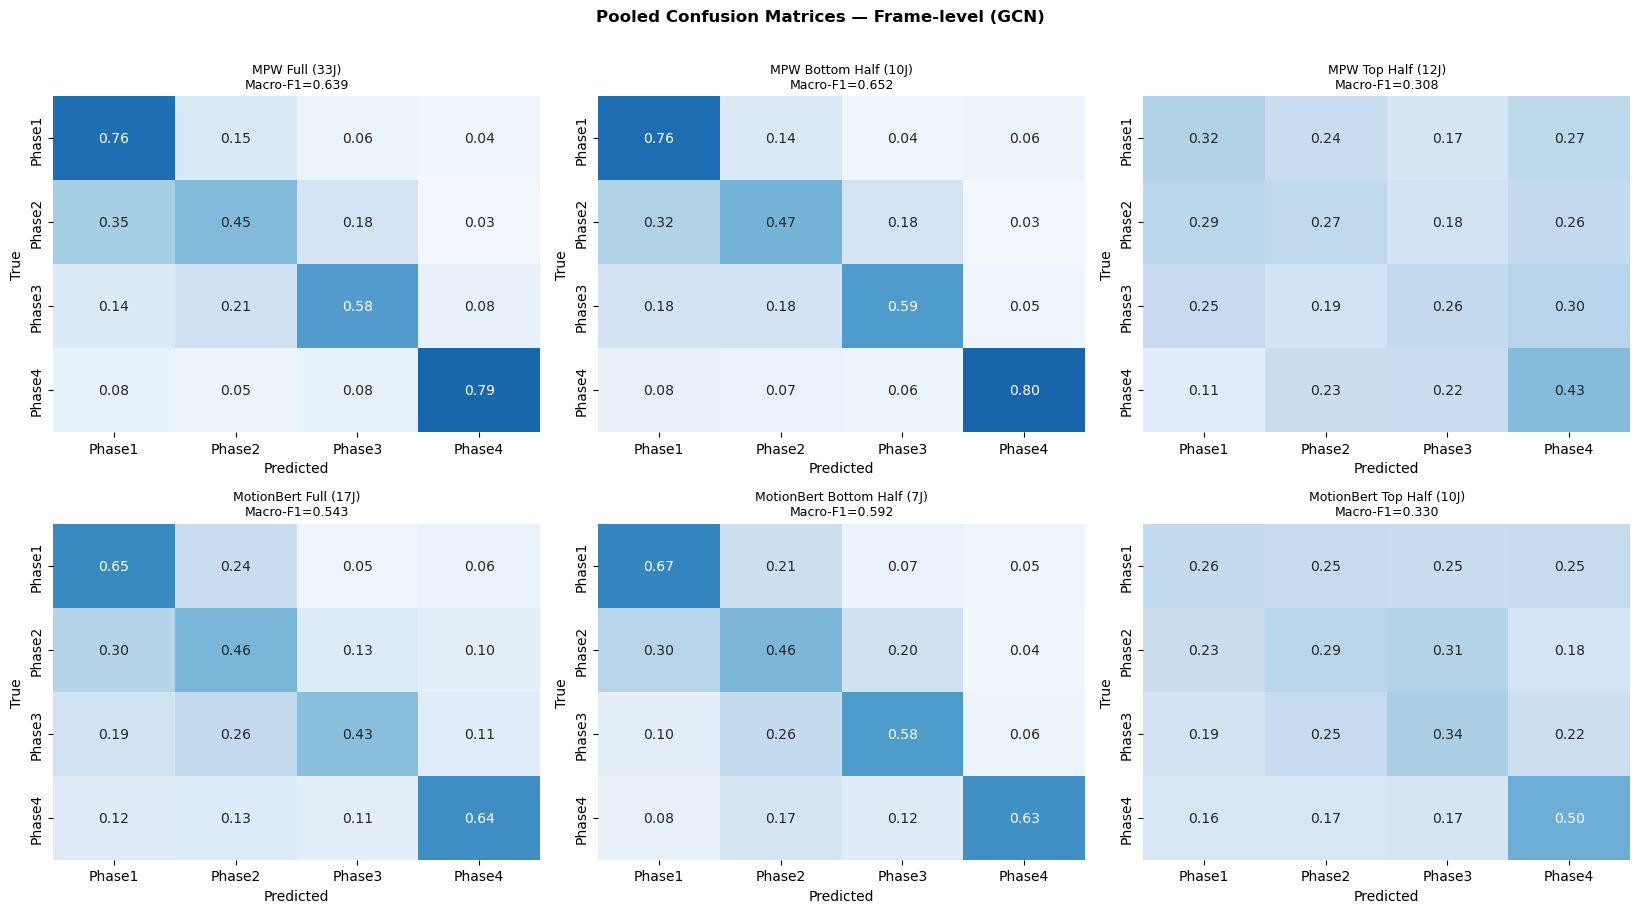

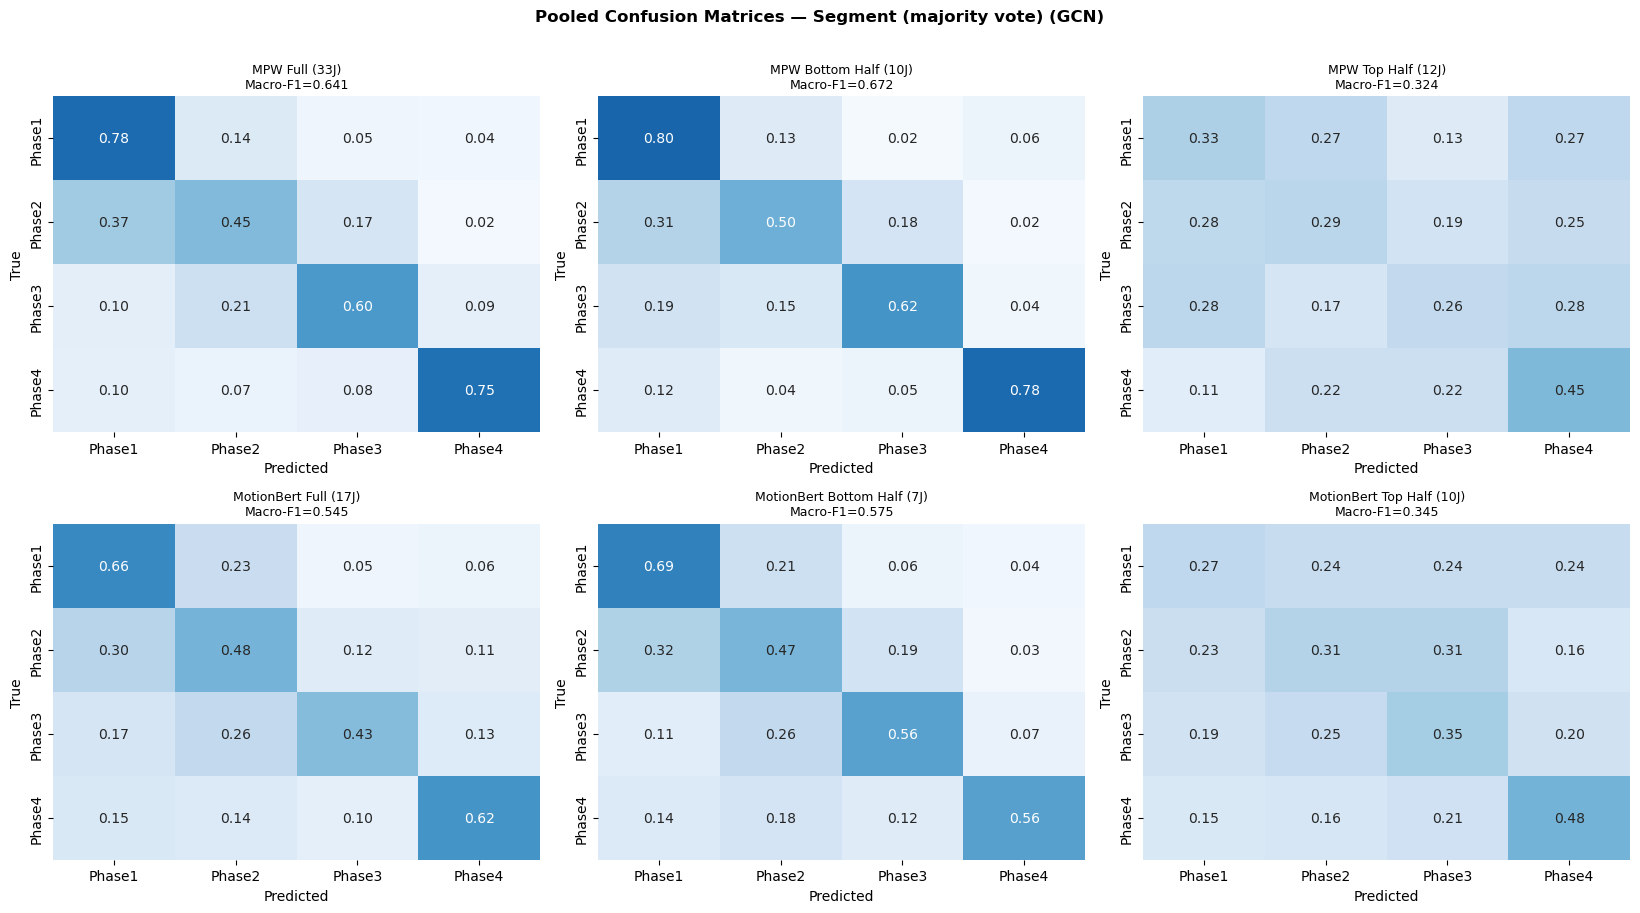

In [9]:
# ── Pooled confusion matrices ─────────────────────────────────────────────────
n_exp = len(all_results)
ncols = min(n_exp, 3)
nrows = (n_exp + ncols - 1) // ncols

for level, cm_key, y_true_key, y_pred_key, title_suffix in [
    ('frame',   'cm_frame', 'y_val',     'y_pred',    'Frame-level'),
    ('segment', 'cm_seg',   'y_true_seg','y_pred_seg', 'Segment (majority vote)'),
]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
    axes = np.array(axes).flatten()
    for ax, (exp_name, fold_results) in zip(axes, all_results.items()):
        if not fold_results:
            ax.set_visible(False)
            continue
        y_true_all = np.concatenate([r[y_true_key] for r in fold_results])
        y_pred_all = np.concatenate([r[y_pred_key] for r in fold_results])
        cm       = confusion_matrix(y_true_all, y_pred_all)
        cm_n     = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        macro_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
        sns.heatmap(cm_n, annot=True, fmt='.2f', ax=ax,
                    xticklabels=PHASE_NAMES, yticklabels=PHASE_NAMES,
                    cmap='Blues', vmin=0, vmax=1, cbar=False)
        ax.set_title(f'{exp_name}\nMacro-F1={macro_f1:.3f}', fontsize=9)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    for ax in axes[n_exp:]:
        ax.set_visible(False)
    plt.suptitle(f'Pooled Confusion Matrices — {title_suffix} (GCN)', y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.show()

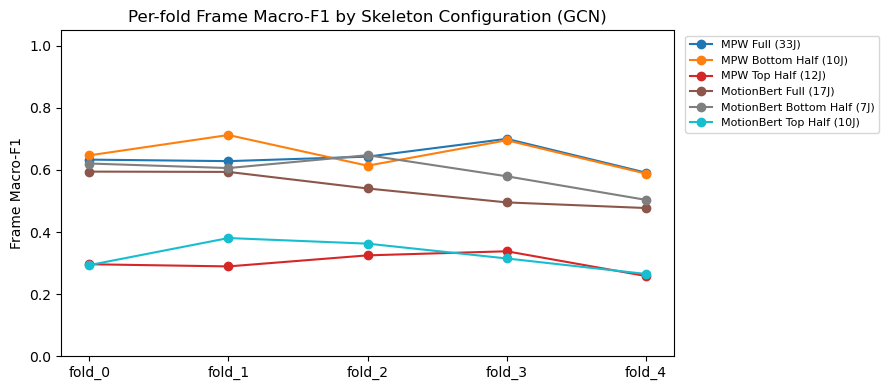

In [10]:
# ── Per-fold macro-F1 line plot ───────────────────────────────────────────────
fold_names = list(splits.keys())
fig, ax    = plt.subplots(figsize=(9, 4))
colors     = plt.cm.tab10(np.linspace(0, 0.9, len(all_results)))

for color, (exp_name, fold_results) in zip(colors, all_results.items()):
    if not fold_results:
        continue
    fold_f1s = {r['fold']: r['frame_f1'] for r in fold_results}
    ys = [fold_f1s.get(fn, np.nan) for fn in fold_names]
    ax.plot(fold_names, ys, marker='o', label=exp_name, color=color)

ax.set_ylabel('Frame Macro-F1')
ax.set_title('Per-fold Frame Macro-F1 by Skeleton Configuration (GCN)')
ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()